In [30]:
!pip install -q rdkit
!pip install -q torch_geometric
!pip install -q xgboost lightgbm optuna 
!pip install torch_geometric
!pip install torch
!pip install plotly
!pip install seaborn
!pip install sklearn       
!pip install XGBoost         


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\sypna\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\sypna\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\sypna\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\sypna\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\sypna\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\sypna\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\sypna\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\sypna\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import AllChem

import torch
import torch_geometric
from torch_geometric.data import Data, Dataset, Batch
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool, BatchNorm

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff

import sklearn
from sklearn.model_selection import train_test_split


# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

import plotly.io as pio


In [3]:
df = pd.read_csv('train.csv')
df_test = pd.read_csv("test.csv")
print(f"Размер датасета: {df.shape}")
print("Пример данных:")
display(df.head())
print(df.isnull().sum())

print(f"Размер  тестового датасета: {df_test.shape}")
print("Пример данных:")
display(df_test.head())
print(df_test.isnull().sum())


Размер датасета: (16328, 4)
Пример данных:


,id,SMILES1,SMILES2,result
0,0,CCC(C)n1ncn(-c2ccc(N3CCN(c4ccc(OCC5COC(Cn6cncn...,O=C(O)C=CC(=O)O,1
1,1,CCC(C)n1ncn(-c2ccc(N3CCN(c4ccc(OCC5COC(Cn6cncn...,O=C(O)CC(=O)O,0
2,2,CCC(C)n1ncn(-c2ccc(N3CCN(c4ccc(OCC5COC(Cn6cncn...,O=C(O)CCC(=O)O,1
3,3,CCC(C)n1ncn(-c2ccc(N3CCN(c4ccc(OCC5COC(Cn6cncn...,O=C(O)CC(O)C(=O)O,1
4,4,CCC(C)n1ncn(-c2ccc(N3CCN(c4ccc(OCC5COC(Cn6cncn...,O=C(O)C(O)C(O)C(=O)O,1


id         0
SMILES1    0
SMILES2    0
result     0
dtype: int64
Размер  тестового датасета: (1000, 3)
Пример данных:


,id,SMILES1,SMILES2
0,0,O=C(O)C(=O)O,CCC(C)(C)c1ccc(OCCCCCCCCN2CCCCC2)cc1
1,1,N#Cc1cc2c(nc1N)Nc1ccccc1N=C2NC(=O)c1ccccc1,O=C(O)c1ccccc1
2,2,C#CC(O)(c1ccccc1)c1ccccc1Br,C1CCN2CC3CC(CN4CCCCC34)C2C1
3,3,Cc1ccc(C(=O)NNC(=O)c2ccc(C)cc2O)c(O)c1,CCC(=O)NNC(=O)c1ccc(C)cc1O
4,4,CCNCC,Cn1c([O])c(C(c2ccc(C=O)cc2)c2c(O)n(C)c(=O)n(C)...


id         0
SMILES1    0
SMILES2    0
dtype: int64


Label: 1 (Сокристалл образуется)


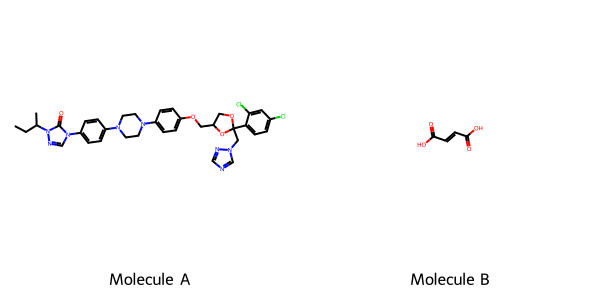

In [4]:
# Всегда перед началом работы стоит посмотреть на данные. Нарисуем пару молекул
def plot_molecule_pair(smiles1, smiles2, label):
    mol1 = Chem.MolFromSmiles(smiles1)
    mol2 = Chem.MolFromSmiles(smiles2)

    if mol1 and mol2:
        img = Draw.MolsToGridImage([mol1, mol2], molsPerRow=2,
                                   subImgSize=(300, 300),
                                   legends=["Molecule A", "Molecule B"])
        print(f"Label: {label} ({'Сокристалл образуется' if label==1 else 'Не образуется'})")
        display(img)
    else:
        print("Ошибка в SMILES строке")

# Визуализируем первую пару из датасета
sample_row = df.iloc[0]
plot_molecule_pair(sample_row['SMILES1'], sample_row['SMILES2'], sample_row['result'])

In [5]:
# slimes1 = df["SMILES1"].to_numpy()
# slimes2 = df["SMILES2"].to_numpy()
smiles_stats1 = df["SMILES1"].str.len().describe()
smiles_stats2 = df["SMILES2"].str.len().describe()

smiles_stats_test1 = df_test["SMILES1"].str.len().describe()
smiles_stats_test2 = df_test["SMILES2"].str.len().describe()

stats_train_df = pd.DataFrame({
    "stats_slimes1_train":smiles_stats1,
    "stats_slimes2_train": smiles_stats2,
})
stats_test_df = pd.DataFrame({
    "stats_slimes1_test":smiles_stats_test2,
    "stats_slimes2_test": smiles_stats_test2,
})
print(stats_train_df)
print(stats_test_df)

       stats_slimes1_train  stats_slimes2_train
count         16328.000000         16328.000000
mean             30.564735            24.612996
std              25.653134            19.929996
min               1.000000             2.000000
25%              17.000000            15.000000
50%              23.000000            20.000000
75%              36.000000            28.000000
max             440.000000           416.000000
       stats_slimes1_test  stats_slimes2_test
count         1000.000000         1000.000000
mean            29.063000           29.063000
std             22.407747           22.407747
min              4.000000            4.000000
25%             17.000000           17.000000
50%             24.000000           24.000000
75%             36.000000           36.000000
max            307.000000          307.000000


C:\Users\sypna\AppData\Local\Temp\ipykernel_20012\2701900985.py:34: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\sypna\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


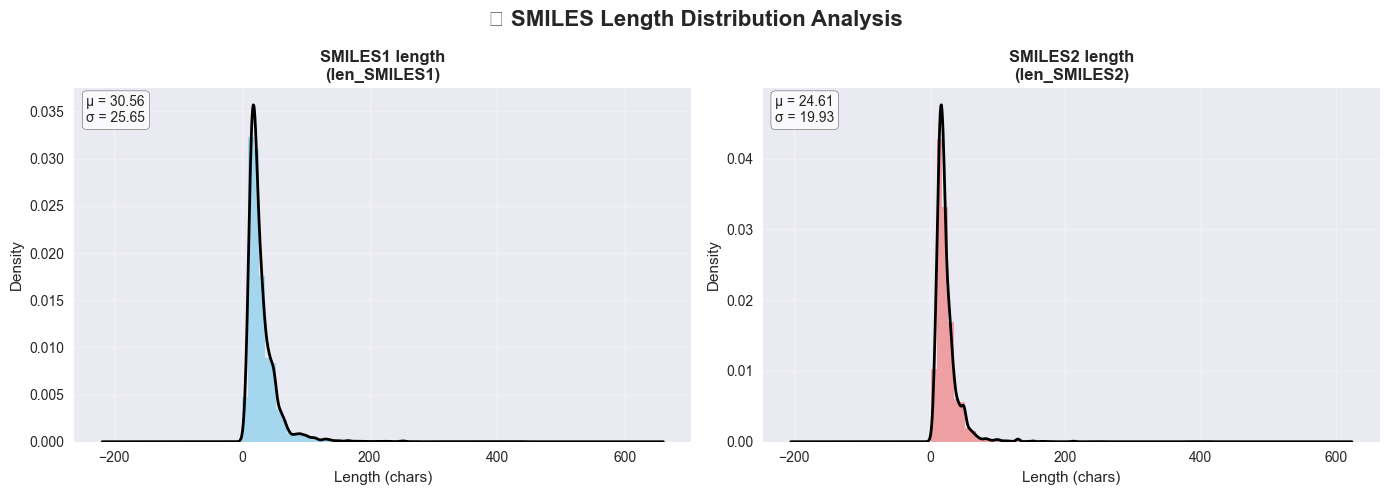

📈 SMILES Lengths Statistical Summary:
       len_SMILES1  len_SMILES2
count     16328.00     16328.00
mean         30.56        24.61
std          25.65        19.93
min           1.00         2.00
25%          17.00        15.00
50%          23.00        20.00
75%          36.00        28.00
max         440.00       416.00

🚨 Outlier Analysis (using IQR method):
• len_SMILES1: 968 outliers (5.9%)
• len_SMILES2: 1276 outliers (7.8%)

🔗 Correlation between SMILES lengths:
             len_SMILES1  len_SMILES2
len_SMILES1        1.000        0.217
len_SMILES2        0.217        1.000


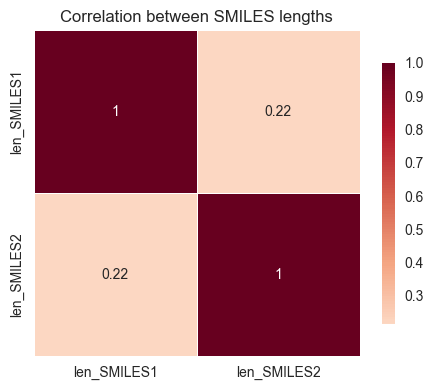

In [6]:
df['len_SMILES1'] = df['SMILES1'].astype(str).str.len()
df['len_SMILES2'] = df['SMILES2'].astype(str).str.len()
len_cols = ['len_SMILES1', 'len_SMILES2']

# Информация для оформления
len_info = {
    'len_SMILES1': {'unit': 'chars', 'name': 'SMILES1 length', 'color': 'skyblue'},
    'len_SMILES2': {'unit': 'chars', 'name': 'SMILES2 length', 'color': 'lightcoral'}
}

# Создаём фигуру с нужным числом subplot (1 строка, 2 столбца)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('📏 SMILES Length Distribution Analysis', fontsize=16, fontweight='bold')

for idx, col in enumerate(len_cols):
    ax = axes[idx]
    
    # Гистограмма (нормированная на плотность) + KDE
    df[col].hist(bins=50, alpha=0.7, ax=ax, color=len_info[col]['color'], density=True)
    df[col].plot.kde(ax=ax, color='black', linewidth=2)
    
    ax.set_title(f'{len_info[col]["name"]}\n({col})', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'Length ({len_info[col]["unit"]})')
    ax.set_ylabel('Density')
    ax.grid(True, alpha=0.3)
    
    # Статистика
    mean_val = df[col].mean()
    std_val = df[col].std()
    ax.text(0.02, 0.98, f'μ = {mean_val:.2f}\nσ = {std_val:.2f}', 
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print("📈 SMILES Lengths Statistical Summary:")
print(df[len_cols].describe().round(2))

print("\n🚨 Outlier Analysis (using IQR method):")
for col in len_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    print(f"• {col}: {outliers} outliers ({outliers/len(df)*100:.1f}%)")

print("\n🔗 Correlation between SMILES lengths:")
corr = df[len_cols].corr()
print(corr.round(3))

# Визуализация корреляции (если интересно)
plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation between SMILES lengths')
plt.tight_layout()
plt.show()

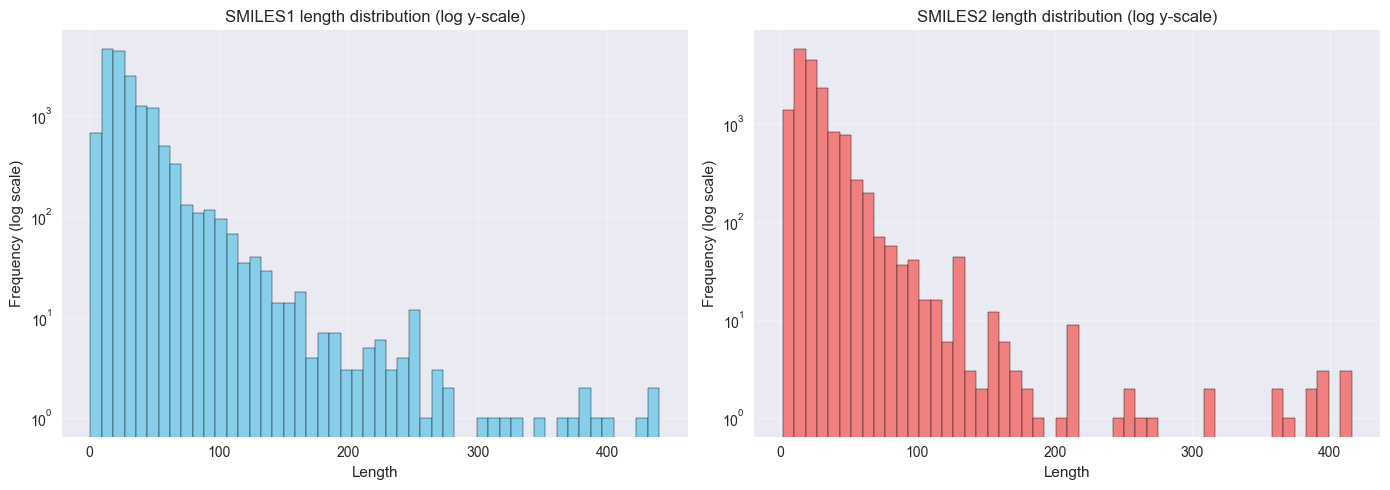

In [7]:
"""train_df"""
df['len1'] = df['SMILES1'].astype(str).str.len()
df['len2'] = df['SMILES2'].astype(str).str.len()

# Построим гистограммы для каждой колонки с логарифмической шкалой по Y
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Для SMILES1
axes[0].hist(df['len1'], bins=50, color='skyblue', edgecolor='black', log=True)
axes[0].set_title('SMILES1 length distribution (log y-scale)')
axes[0].set_xlabel('Length')
axes[0].set_ylabel('Frequency (log scale)')
axes[0].grid(True, alpha=0.3)

# Для SMILES2
axes[1].hist(df['len2'], bins=50, color='lightcoral', edgecolor='black', log=True)
axes[1].set_title('SMILES2 length distribution (log y-scale)')
axes[1].set_xlabel('Length')
axes[1].set_ylabel('Frequency (log scale)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

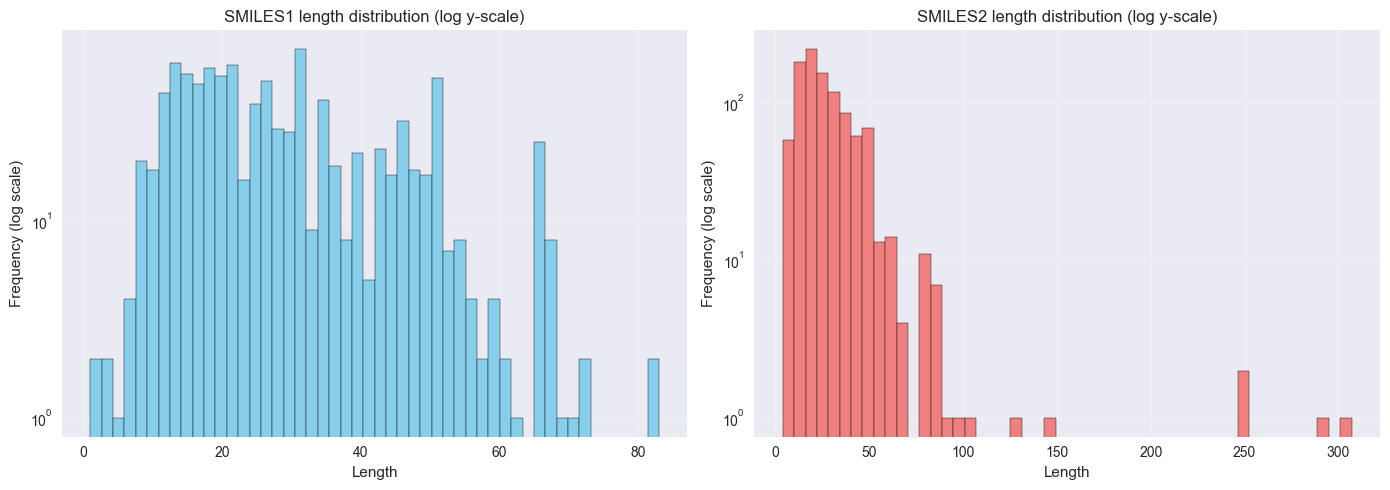

test
            len1         len2
count  1000.0000  1000.000000
mean     29.0850    29.063000
std      15.0167    22.407747
min       1.0000     4.000000
25%      17.0000    17.000000
50%      26.0000    24.000000
75%      39.0000    36.000000
max      83.0000   307.000000
train
               len1          len2
count  16328.000000  16328.000000
mean      30.564735     24.612996
std       25.653134     19.929996
min        1.000000      2.000000
25%       17.000000     15.000000
50%       23.000000     20.000000
75%       36.000000     28.000000
max      440.000000    416.000000


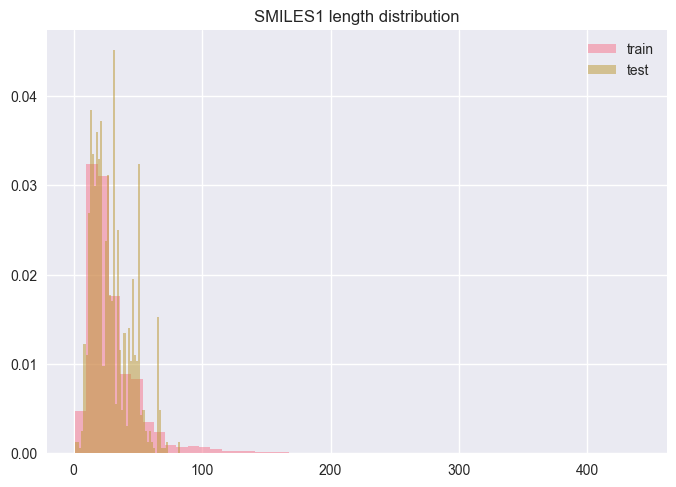

In [8]:
"""testdf"""
df_test['len1'] = df_test['SMILES1'].astype(str).str.len()
df_test['len2'] = df_test['SMILES2'].astype(str).str.len()

# Построим гистограммы для каждой колонки с логарифмической шкалой по Y
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Для SMILES1
axes[0].hist(df_test['len1'], bins=50, color='skyblue', edgecolor='black', log=True)
axes[0].set_title('SMILES1 length distribution (log y-scale)')
axes[0].set_xlabel('Length')
axes[0].set_ylabel('Frequency (log scale)')
axes[0].grid(True, alpha=0.3)

# Для SMILES2
axes[1].hist(df_test['len2'], bins=50, color='lightcoral', edgecolor='black', log=True)
axes[1].set_title('SMILES2 length distribution (log y-scale)')
axes[1].set_xlabel('Length')
axes[1].set_ylabel('Frequency (log scale)')
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()
print("test")
print(df_test[['len1', 'len2']].describe())
print("train")
print(df[['len1', 'len2']].describe())
plt.hist(df['len1'], bins=50, alpha=0.5, label='train', density=True)
plt.hist(df_test['len1'], bins=50, alpha=0.5, label='test', density=True)
plt.legend()
plt.title('SMILES1 length distribution')
plt.show()

In [9]:
threshold = 310

# Найдём индексы строк, где длина SMILES1 > threshold ИЛИ SMILES2 > threshold
long_mask = (df['len1'] > threshold) | (df['len2'] > threshold)
long_df = df[long_mask].copy()  # копия для анализа
print(f"Найдено {len(long_df)} строк с длиной SMILES > {threshold} символов.")
df.describe()
def delete_long_lines(df):
    ids = long_df.id
    df_trimmed = df.drop(ids)
    df.reset_index(drop=True)
    return df_trimmed

df_trimmed = delete_long_lines(df)
df_trimmed['len1'] = df_trimmed['SMILES1'].str.len()
df_trimmed['len2'] = df_trimmed['SMILES2'].str.len()
print(df_trimmed[['len1', 'len2']].describe())

Найдено 13 строк с длиной SMILES > 310 символов.
               len1          len2
count  16315.000000  16315.000000
mean      30.288017     24.350720
std       23.685640     17.402615
min        1.000000      2.000000
25%       17.000000     15.000000
50%       23.000000     20.000000
75%       36.000000     28.000000
max      308.000000    310.000000


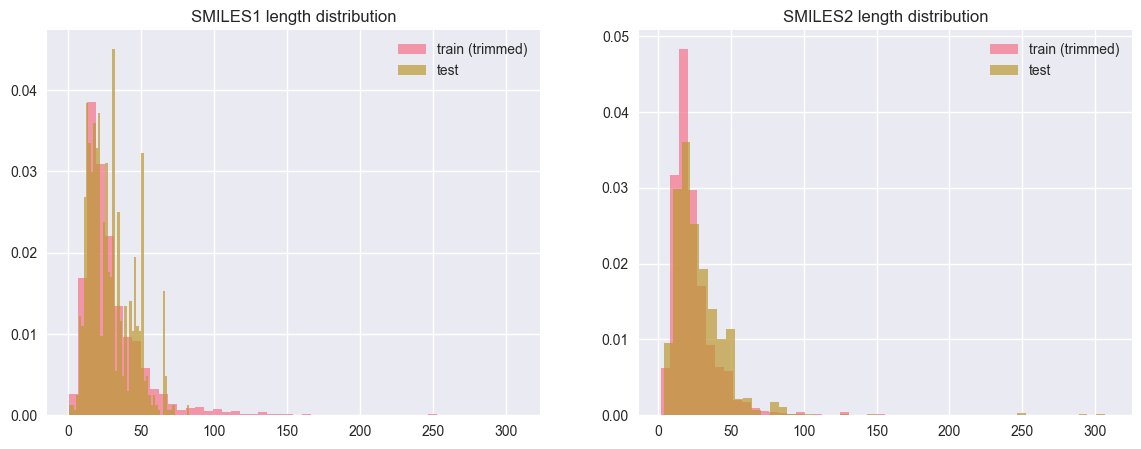

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].hist(df_trimmed['len1'], bins=50, alpha=0.7, density=True, label='train (trimmed)')
axes[0].hist(df_test['SMILES1'].str.len(), bins=50, alpha=0.7, density=True, label='test')
axes[0].set_title('SMILES1 length distribution')
axes[0].legend()

# SMILES2
axes[1].hist(df_trimmed['len2'], bins=50, alpha=0.7, density=True, label='train (trimmed)')
axes[1].hist(df_test['SMILES2'].str.len(), bins=50, alpha=0.7, density=True, label='test')
axes[1].set_title('SMILES2 length distribution')
axes[1].legend()

plt.show()

PART2

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINEConv, global_mean_pool, global_max_pool, BatchNorm
from torch_geometric.data import Data
from rdkit import Chem

# Константы для размерностей
BOND_FEAT_DIM = 4  # Используем 4 признака связи (одинарная, двойная, тройная, ароматическая)

PERMITTED_ATOM_TYPES = ['C', 'N', 'O', 'S', 'F', 'Cl', 'Br', 'I', 'P', 'Unknown']

def one_hot_encoding(x, allowable_set, include_other=True):
    """
    One-hot encoding с поддержкой категории "другое".
    Если include_other=True, то при отсутствии x в allowable_set возвращается вектор,
    где последний элемент (Other) равен 1.
    """
    if x not in allowable_set:
        if include_other:
            # добавляем категорию "другое" в конец
            vec = [0] * len(allowable_set) + [1]
        else:
            x = allowable_set[-1]
            vec = [int(x == item) for item in allowable_set]
    else:
        vec = [int(x == item) for item in allowable_set]
        if include_other:
            vec.append(0)  # категория "другое" не активна
    return vec

def get_atom_features(atom):
    """
    Расширенные признаки атома с категорией "другое" для всех величин.
    """
    # Тип атома (с Other)
    features = one_hot_encoding(atom.GetSymbol(), PERMITTED_ATOM_TYPES, include_other=False)
    # Для типа атома Other уже включён в PERMITTED_ATOM_TYPES как 'Unknown', поэтому include_other=False

    # Степень (количество соседей)
    degree = atom.GetDegree()
    features += one_hot_encoding(degree, [0, 1, 2, 3, 4, 5], include_other=True)

    # Формальный заряд
    charge = atom.GetFormalCharge()
    features += one_hot_encoding(charge, [-2, -1, 0, 1, 2], include_other=True)

    # Гибридизация
    hybridization = atom.GetHybridization()
    # Преобразуем тип гибридизации в строку для удобства сравнения
    hyb_map = {
        Chem.rdchem.HybridizationType.SP: 'SP',
        Chem.rdchem.HybridizationType.SP2: 'SP2',
        Chem.rdchem.HybridizationType.SP3: 'SP3',
        Chem.rdchem.HybridizationType.SP3D: 'SP3D',
        Chem.rdchem.HybridizationType.SP3D2: 'SP3D2',
    }
    hyb_str = hyb_map.get(hybridization, 'OTHER')
    features += one_hot_encoding(hyb_str, ['SP', 'SP2', 'SP3', 'SP3D', 'SP3D2'], include_other=True)

    # Ароматичность
    features.append(int(atom.GetIsAromatic()))

    # Можно добавить другие признаки (масса, число водородов, донор/акцептор и т.д.)
    # features.append(atom.GetMass())
    # features.append(atom.GetTotalNumHs())
    # features.append(int(atom.IsInRing()))

    return torch.tensor(features, dtype=torch.float)

def get_bond_features(bond):
    """
    Признаки связи: тип (одинарная, двойная, тройная, ароматическая).
    """
    bond_type = bond.GetBondType()
    features = [
        bond_type == Chem.rdchem.BondType.SINGLE,
        bond_type == Chem.rdchem.BondType.DOUBLE,
        bond_type == Chem.rdchem.BondType.TRIPLE,
        bond_type == Chem.rdchem.BondType.AROMATIC,
    ]
    # Можно добавить признаки сопряжённости, принадлежности к кольцу и т.д.
    # features.append(bond.GetIsConjugated())
    # features.append(bond.IsInRing())
    return torch.tensor(features, dtype=torch.float)

def smiles_to_graph(smiles):
    """
    Преобразует SMILES в объект Data для PyG.
    Возвращает None, если SMILES некорректен.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # Признаки атомов
    atom_feats = [get_atom_features(atom) for atom in mol.GetAtoms()]
    x = torch.stack(atom_feats)

    edge_indices = []
    edge_attrs = []

    # Если есть связи, заполняем рёбра
    if mol.GetNumBonds() > 0:
        for bond in mol.GetBonds():
            i = bond.GetBeginAtomIdx()
            j = bond.GetEndAtomIdx()
            bond_feat = get_bond_features(bond)
            # Добавляем в обе стороны
            edge_indices.append([i, j])
            edge_indices.append([j, i])
            edge_attrs.append(bond_feat)
            edge_attrs.append(bond_feat)

        edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
        edge_attr = torch.stack(edge_attrs)
    else:
        # Молекула без связей (одиночный атом)
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr = torch.empty((0, BOND_FEAT_DIM), dtype=torch.float)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)

class ImprovedGNNEncoder(nn.Module):
    def __init__(self, node_dim, edge_dim, hidden_dim=64, output_dim=32):
        super().__init__()
        self.conv1 = GINEConv(nn.Sequential(
            nn.Linear(node_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        ), edge_dim=edge_dim)
        self.bn1 = BatchNorm(hidden_dim)

        self.conv2 = GINEConv(nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        ), edge_dim=edge_dim)
        self.bn2 = BatchNorm(hidden_dim)

        self.conv3 = GINEConv(nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        ), edge_dim=edge_dim)
        self.bn3 = BatchNorm(output_dim)

        self.dropout = nn.Dropout(0.2)

    def forward(self, x, edge_index, edge_attr, batch):
        x = self.conv1(x, edge_index, edge_attr)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index, edge_attr)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index, edge_attr)
        x = self.bn3(x)  # без активации перед пулингом

        # Комбинируем mean и max пулинг
        x_mean = global_mean_pool(x, batch)
        x_max = global_max_pool(x, batch)
        x = torch.cat([x_mean, x_max], dim=1)
        return x

In [12]:

x_train, x_test, y_train, ytest = train_test_split(
    df,df["result"], test_size=0.2, random_state=42, stratify=df['result']
)

In [14]:
from tqdm import tqdm
target_col = 'result'

def prepare_gnn_data(df, smiles_col1='SMILES1', smiles_col2='SMILES2', target_col='result'):
    """
    Преобразует SMILES в графы. Если целевая колонка присутствует, возвращает метки.
    """
    graphs1, graphs2, targets = [], [], []
    has_target = target_col in df.columns  # проверяем, есть ли колонка с метками

    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Converting SMILES to graphs"):
        g1 = smiles_to_graph(row[smiles_col1])
        g2 = smiles_to_graph(row[smiles_col2])
        if g1 is not None and g2 is not None:
            graphs1.append(g1)
            graphs2.append(g2)
            if has_target:
                targets.append(row[target_col])

    if has_target:
        targets = torch.tensor(targets, dtype=torch.float).view(-1, 1)
    else:
        targets = None

    print(f"Успешно преобразовано {len(graphs1)} пар.")
    return graphs1, graphs2, targets

# Разделение на train/val (уже сделано ранее)
train_df, val_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['result']
)

X_train1, X_train2, y_train = prepare_gnn_data(train_df)
X_val1, X_val2, y_val = prepare_gnn_data(val_df)

Converting SMILES to graphs:   0%|          | 0/13062 [00:00<?, ?it/s]

Converting SMILES to graphs: 100%|██████████| 13062/13062 [00:26<00:00, 496.98it/s]


Успешно преобразовано 13062 пар.


Converting SMILES to graphs: 100%|██████████| 3266/3266 [00:06<00:00, 534.28it/s]

Успешно преобразовано 3266 пар.


In [15]:
class BilinearInteraction(nn.Module):
    def __init__(self, dim1, dim2, out_dim=1):
        super().__init__()
        self.fc1 = nn.Linear(dim1, out_dim)
        self.fc2 = nn.Linear(dim2, out_dim)
    def forward(self, emb1, emb2):
        return self.fc1(emb1) * self.fc2(emb2)

class SiameseGNN(nn.Module):
    def __init__(self, node_dim, edge_dim, hidden_dim=64, embedding_dim=32):
        super().__init__()
        # Энкодер один на обе молекулы
        self.encoder = ImprovedGNNEncoder(node_dim, edge_dim, hidden_dim, embedding_dim)
        # После пулинга размер эмбеддинга = embedding_dim * 2 (mean+max)
        self.interaction = BilinearInteraction(embedding_dim*2, embedding_dim*2)
        self.sigmoid = nn.Sigmoid()

    def forward(self, mol1, mol2):
        emb1 = self.encoder(mol1.x, mol1.edge_index, mol1.edge_attr, mol1.batch)
        emb2 = self.encoder(mol2.x, mol2.edge_index, mol2.edge_attr, mol2.batch)
        out = self.interaction(emb1, emb2)  # билинейное взаимодействие
        return self.sigmoid(out)

In [16]:
n_pos = (y_train == 1).sum().item()
n_neg = (y_train == 0).sum().item()
pos_weight = n_neg / n_pos

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(device))

In [18]:
from torch_geometric.data import Dataset, Data

class PairDataset(Dataset):
    def __init__(self, graphs1, graphs2, targets):
        super().__init__()
        self.graphs1 = graphs1
        self.graphs2 = graphs2
        self.targets = targets

    def len(self):
        return len(self.targets)

    def get(self, idx):
        mol1 = self.graphs1[idx]
        mol2 = self.graphs2[idx]
        label = self.targets[idx]
        # Важно: возвращаем словарь или кортеж, чтобы DataLoader мог сформировать батч
        return mol1, mol2, label

In [19]:
from torch_geometric.loader import DataLoader

batch_size = 32  # можно поэкспериментировать

train_dataset = PairDataset(X_train1, X_train2, y_train)
val_dataset = PairDataset(X_val1, X_val2, y_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [20]:
n_pos = (y_train == 1).sum().item()
n_neg = (y_train == 0).sum().item()
pos_weight = n_neg / n_pos
print(f"pos_weight = {pos_weight:.3f}")


pos_weight = 0.129


In [21]:
node_dim = X_train1[0].x.size(1)
edge_dim = X_train1[0].edge_attr.size(1)
print(f"node_dim: {node_dim}, edge_dim: {edge_dim}")


node_dim: 30, edge_dim: 4


In [22]:
model = SiameseGNN(node_dim, edge_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(device))

In [25]:
def weighted_accuracy(y_true, y_pred_probs, threshold=0.5):
    y_true = y_true.cpu().numpy().flatten()
    y_pred = (y_pred_probs.cpu().numpy().flatten() > threshold).astype(int)
    weights = np.where(y_true == 1, 0.3, 0.7)
    correct = (y_true == y_pred).astype(float)
    return np.sum(weights * correct) / np.sum(weights)

num_epochs = 50
patience = 15
best_val_wa = 0.0
patience_counter = 0
best_model_state = None

for epoch in range(1, num_epochs+1):
    model.train()
    total_loss = 0.0
    for batch in train_loader:
        mol1, mol2, labels = batch
        mol1, mol2, labels = mol1.to(device), mol2.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(mol1, mol2)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)
    avg_train_loss = total_loss / len(train_dataset)
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in val_loader:
            mol1, mol2, labels = batch
            mol1, mol2, labels = mol1.to(device), mol2.to(device), labels.to(device)
            logits = model(mol1, mol2)
            loss = criterion(logits, labels)
            val_loss += loss.item() * len(labels)
            probs = torch.sigmoid(logits)
            all_preds.append(probs.cpu())
            all_labels.append(labels.cpu())
    avg_val_loss = val_loss / len(val_dataset)
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    val_wa = weighted_accuracy(all_labels, all_preds)

    print(f"Epoch {epoch:2d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val WA: {val_wa:.4f}")
    if val_wa > best_val_wa:
        best_val_wa = val_wa
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

Epoch  1 | Train Loss: 0.1417 | Val Loss: 0.1385 | Val WA: 0.7844
Epoch  2 | Train Loss: 0.1400 | Val Loss: 0.1373 | Val WA: 0.8018
Epoch  3 | Train Loss: 0.1403 | Val Loss: 0.1393 | Val WA: 0.7839
Epoch  4 | Train Loss: 0.1403 | Val Loss: 0.1389 | Val WA: 0.7825
Epoch  5 | Train Loss: 0.1395 | Val Loss: 0.1372 | Val WA: 0.7946
Epoch  6 | Train Loss: 0.1392 | Val Loss: 0.1365 | Val WA: 0.7992
Epoch  7 | Train Loss: 0.1394 | Val Loss: 0.1384 | Val WA: 0.7900
Epoch  8 | Train Loss: 0.1392 | Val Loss: 0.1377 | Val WA: 0.7931
Epoch  9 | Train Loss: 0.1393 | Val Loss: 0.1382 | Val WA: 0.7881
Epoch 10 | Train Loss: 0.1395 | Val Loss: 0.1387 | Val WA: 0.7999
Epoch 11 | Train Loss: 0.1392 | Val Loss: 0.1373 | Val WA: 0.7979
Epoch 12 | Train Loss: 0.1385 | Val Loss: 0.1379 | Val WA: 0.8026
Epoch 13 | Train Loss: 0.1382 | Val Loss: 0.1387 | Val WA: 0.7865
Epoch 14 | Train Loss: 0.1389 | Val Loss: 0.1374 | Val WA: 0.7993
Epoch 15 | Train Loss: 0.1383 | Val Loss: 0.1389 | Val WA: 0.7872
Epoch 16 |

In [26]:
model.load_state_dict(best_model_state)
model.to(device)
print(f"Best validation weighted accuracy: {best_val_wa:.4f}")
model.eval()
val_probs_gnn = []
with torch.no_grad():
    for batch in val_loader:
        mol1, mol2, _ = batch
        mol1, mol2 = mol1.to(device), mol2.to(device)
        logits = model(mol1, mol2)
        probs = torch.sigmoid(logits)
        val_probs_gnn.append(probs.cpu().numpy())
val_probs_gnn = np.concatenate(val_probs_gnn).flatten()

Best validation weighted accuracy: 0.8063


In [35]:
from rdkit import Chem
from rdkit.Chem import Descriptors, MACCSkeys
from rdkit.Chem.rdMolDescriptors import GetMorganFingerprintAsBitVect
X_test1, X_test2, _ = prepare_gnn_data(df_test)
test_dataset = PairDataset(X_test1, X_test2, torch.zeros(len(X_test1)))
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
test_probs_gnn = []
with torch.no_grad():
    for batch in test_loader:
        mol1, mol2, _ = batch
        mol1, mol2 = mol1.to(device), mol2.to(device)
        logits = model(mol1, mol2)
        probs = torch.sigmoid(logits)
        test_probs_gnn.append(probs.cpu().numpy())
test_probs_gnn = np.concatenate(test_probs_gnn).flatten()

print(f"GNN val probs shape: {val_probs_gnn.shape}")
print(f"GNN test probs shape: {test_probs_gnn.shape}")

def get_mol_features(smiles):
    """Возвращает вектор признаков для одной молекулы."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    desc = [
        Descriptors.MolLogP(mol),
        Descriptors.MolWt(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.TPSA(mol),
        Descriptors.NumRotatableBonds(mol),
        Descriptors.RingCount(mol)
    ]
    morgan = list(GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024))
    maccs = list(MACCSkeys.GenMACCSKeys(mol))
    return np.array(desc + morgan + maccs)

def pair_features(smiles1, smiles2):
    """Возвращает вектор признаков для пары молекул."""
    f1 = get_mol_features(smiles1)
    f2 = get_mol_features(smiles2)
    if f1 is None or f2 is None:
        return None
    # Конкатенация + разность первых 7 дескрипторов
    diff = f1[:7] - f2[:7]
    return np.concatenate([f1, f2, diff])

def build_xgb_data(df, target_col='result'):
    X_list, y_list = [], []
    has_target = target_col in df.columns  # проверяем наличие колонки с метками
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="XGB features"):
        feat = pair_features(row['SMILES1'], row['SMILES2'])
        if feat is not None:
            X_list.append(feat)
            if has_target:
                y_list.append(row[target_col])
    X = np.array(X_list)
    y = np.array(y_list) if has_target else None
    return X, y

# Используем те же разбиения train/val
X_train_xgb, y_train_xgb = build_xgb_data(train_df)
X_val_xgb, y_val_xgb = build_xgb_data(val_df)
print(f"X_train_xgb shape: {X_train_xgb.shape}")
print(f"X_val_xgb shape: {X_val_xgb.shape}")


Converting SMILES to graphs: 100%|██████████| 1000/1000 [00:03<00:00, 282.17it/s]


Успешно преобразовано 1000 пар.
GNN val probs shape: (3266,)
GNN test probs shape: (1000,)


XGB features:   0%|          | 0/13062 [00:00<?, ?it/s][17:09:26] DEPRECATION WARNING: please use MorganGenerator
[17:09:26] DEPRECATION WARNING: please use MorganGenerator
[17:09:26] DEPRECATION WARNING: please use MorganGenerator
[17:09:26] DEPRECATION WARNING: please use MorganGenerator
[17:09:26] DEPRECATION WARNING: please use MorganGenerator
[17:09:26] DEPRECATION WARNING: please use MorganGenerator
[17:09:26] DEPRECATION WARNING: please use MorganGenerator
[17:09:26] DEPRECATION WARNING: please use MorganGenerator
[17:09:26] DEPRECATION WARNING: please use MorganGenerator
[17:09:26] DEPRECATION WARNING: please use MorganGenerator
[17:09:26] DEPRECATION WARNING: please use MorganGenerator
[17:09:26] DEPRECATION WARNING: please use MorganGenerator
[17:09:26] DEPRECATION WARNING: please use MorganGenerator
[17:09:26] DEPRECATION WARNING: please use MorganGenerator
[17:09:26] DEPRECATION WARNING: please use MorganGenerator
[17:09:26] DEPRECATION WARNING: please use MorganGenerator
[

X_train_xgb shape: (13062, 2403)
X_val_xgb shape: (3266, 2403)


In [36]:
scale_pos_weight = (y_train_xgb == 0).sum() / (y_train_xgb == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.3f}")

model_xgb = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=20   # добавили сюда
)

model_xgb.fit(
    X_train_xgb, y_train_xgb,
    eval_set=[(X_val_xgb, y_val_xgb)],
    verbose=False
)
val_probs_xgb = model_xgb.predict_proba(X_val_xgb)[:, 1]
# Для теста нужно построить признаки
X_test_xgb, _ = build_xgb_data(df_test)  
test_probs_xgb = model_xgb.predict_proba(X_test_xgb)[:, 1]
print(f"XGB val probs shape: {val_probs_xgb.shape}")
print(f"XGB test probs shape: {test_probs_xgb.shape}")

best_w = 0.5
best_wa = 0.0
for w in np.arange(0, 1.01, 0.05):
    ens_val = w * val_probs_gnn + (1 - w) * val_probs_xgb
    wa = weighted_accuracy(torch.tensor(y_val.numpy()), torch.tensor(ens_val))
    if wa > best_wa:
        best_wa = wa
        best_w = w

print(f"Best weight for GNN: {best_w:.2f}, weighted accuracy = {best_wa:.4f}")
test_probs_ensemble = best_w * test_probs_gnn + (1 - best_w) * test_probs_xgb

scale_pos_weight = 0.129


C:\Users\sypna\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\callback.py:385: UserWarning: [17:11:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
XGB features:   0%|          | 0/1000 [00:00<?, ?it/s][17:11:58] DEPRECATION WARNING: please use MorganGenerator
[17:11:58] DEPRECATION WARNING: please use MorganGenerator
[17:11:58] DEPRECATION WARNING: please use MorganGenerator
[17:11:58] DEPRECATION WARNING: please use MorganGenerator
[17:11:58] DEPRECATION WARNING: please use MorganGenerator
[17:11:58] DEPRECATION WARNING: please use MorganGenerator
[17:11:58] DEPRECATION WARNING: please use MorganGenerator
[17:11:58] DEPRECATION WARNING: please use MorganGenerator
[17:11:58] DEPRECATION WARNING: please use MorganGenerator
[17:11:58] DEPRECATION WARNING: please use MorganGenera

XGB val probs shape: (3266,)
XGB test probs shape: (1000,)
Best weight for GNN: 0.35, weighted accuracy = 0.9453


In [37]:
submission = pd.DataFrame({
    'id': df_test['id'],
    'result': (test_probs_ensemble > 0.5).astype(int)
})
submission.to_csv('submission.csv', index=False)
print("Submission saved to submission.csv")
print(submission.head())

Submission saved to submission.csv
   id  result
0   0       1
1   1       1
2   2       1
3   3       1
4   4       1
